In [1]:
import pandas as pd
import numpy as np

# Load the feature-engineered dataset
file_path = "../data/retail_sales_features.csv"

df = pd.read_csv(file_path)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 73000
Columns: 26


In [2]:
# Create store-level summary

store_data = df.groupby(
    ["Store_ID", "Store_Location", "Region"]
).agg(
    Total_Sales=("Total_Sales", "sum"),
    Total_Units_Sold=("Units_Sold", "sum"),
    Average_Unit_Price=("Unit_Price", "mean"),
    Average_Discount=("Discount_Percentage", "mean"),
    Average_Stock=("Stock_On_Hand", "mean"),
    Average_Store_Rating=("Store_Rating", "mean")
).reset_index()

print("Store-level dataset created successfully!")
print("Number of stores:", store_data.shape[0])
print("Columns:", store_data.shape[1])

store_data.head()

Store-level dataset created successfully!
Number of stores: 8
Columns: 9


,Store_ID,Store_Location,Region,Total_Sales,Total_Units_Sold,Average_Unit_Price,Average_Discount,Average_Stock,Average_Store_Rating
0,STR_101,Mumbai,West,5.751484e+09,226670,25283.362189,10.091824,274.836486,4.250183
1,STR_102,Bangalore,South,5.758117e+09,228384,24962.796791,9.998365,277.107151,4.250981
2,STR_103,Delhi,North,5.803047e+09,229475,25105.934237,9.968931,275.589883,4.250714
3,STR_104,Chennai,South,5.749821e+09,228580,25155.350446,10.113760,273.573155,4.250501
4,STR_105,Pune,West,5.737160e+09,227715,25241.357880,10.076724,273.825805,4.245418


In [3]:
# Select features for store segmentation

segmentation_features = [
    "Total_Sales",
    "Total_Units_Sold",
    "Average_Unit_Price",
    "Average_Discount",
    "Average_Stock",
    "Average_Store_Rating"
]

X = store_data[segmentation_features]

print("Segmentation features selected:")
print(segmentation_features)

print("\nFeature dataset shape:", X.shape)

X.head()

Segmentation features selected:
['Total_Sales', 'Total_Units_Sold', 'Average_Unit_Price', 'Average_Discount', 'Average_Stock', 'Average_Store_Rating']

Feature dataset shape: (8, 6)


,Total_Sales,Total_Units_Sold,Average_Unit_Price,Average_Discount,Average_Stock,Average_Store_Rating
0,5.751484e+09,226670,25283.362189,10.091824,274.836486,4.250183
1,5.758117e+09,228384,24962.796791,9.998365,277.107151,4.250981
2,5.803047e+09,229475,25105.934237,9.968931,275.589883,4.250714
3,5.749821e+09,228580,25155.350446,10.113760,273.573155,4.250501
4,5.737160e+09,227715,25241.357880,10.076724,273.825805,4.245418


In [4]:
from sklearn.preprocessing import StandardScaler

# Scale the segmentation features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print("Scaled dataset shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Features scaled successfully!
Scaled dataset shape: (8, 6)

First 5 scaled rows:
[[ 0.5838972  -0.21758689  1.43113338  1.20100791  0.15752895  0.43868781]
 [ 0.6858995   0.53869992 -1.21940371 -0.1731837   1.81240739  0.90215833]
 [ 1.376781    1.02009369 -0.03589759 -0.60597591  0.70661077  0.74719361]
 [ 0.55833681  0.62518313  0.3726914   1.52354301 -0.76319724  0.62339302]
 [ 0.36364672  0.24350979  1.08382833  0.97897232 -0.5790637  -2.32669496]]


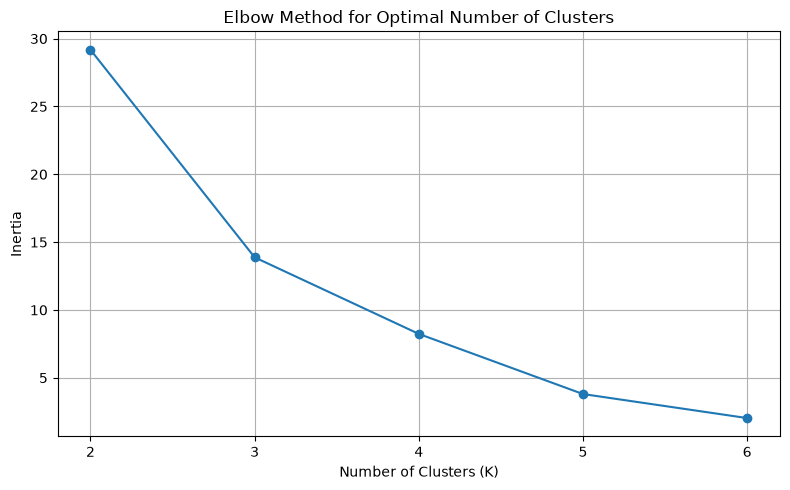

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 7))
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores[k] = score

print("===== SILHOUETTE SCORES =====")

for k, score in silhouette_scores.items():
    print(f"K = {k}: {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)

print("\nBest K based on Silhouette Score:", best_k)

===== SILHOUETTE SCORES =====
K = 2: 0.3457
K = 3: 0.4246
K = 4: 0.3921
K = 5: 0.3581

Best K based on Silhouette Score: 3


In [7]:
# Create final K-Means model with 3 clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Assign each store to a cluster
store_data["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

print("\nStores in each cluster:")
print(store_data["Cluster"].value_counts().sort_index())

print("\nStore cluster assignments:")
print(
    store_data[
        ["Store_ID", "Store_Location", "Region", "Total_Sales", "Cluster"]
    ].sort_values("Cluster")
)

K-Means clustering completed successfully!

Stores in each cluster:
Cluster
0    3
1    2
2    3
Name: count, dtype: int64

Store cluster assignments:
  Store_ID Store_Location Region   Total_Sales  Cluster
1  STR_102      Bangalore  South  5.758117e+09        0
2  STR_103          Delhi  North  5.803047e+09        0
6  STR_107        Kolkata   East  5.672850e+09        0
5  STR_106      Hyderabad  South  5.601443e+09        1
7  STR_108      Ahmedabad   West  5.634170e+09        1
0  STR_101         Mumbai   West  5.751484e+09        2
3  STR_104        Chennai  South  5.749821e+09        2
4  STR_105           Pune   West  5.737160e+09        2


In [8]:
# Analyze the characteristics of each cluster

cluster_summary = store_data.groupby("Cluster").agg(
    Number_of_Stores=("Store_ID", "count"),
    Average_Total_Sales=("Total_Sales", "mean"),
    Average_Units_Sold=("Total_Units_Sold", "mean"),
    Average_Unit_Price=("Average_Unit_Price", "mean"),
    Average_Discount=("Average_Discount", "mean"),
    Average_Stock=("Average_Stock", "mean"),
    Average_Store_Rating=("Average_Store_Rating", "mean")
).reset_index()

print("===== CLUSTER SUMMARY =====")

cluster_summary

===== CLUSTER SUMMARY =====


,Cluster,Number_of_Stores,Average_Total_Sales,Average_Units_Sold,Average_Unit_Price,Average_Discount,Average_Stock,Average_Store_Rating
0,0,3,5.744671e+09,229087.333333,24992.201903,9.973045,276.179039,4.249956
1,1,2,5.617806e+09,223539.000000,25112.765170,9.939852,273.095080,4.249723
2,2,3,5.746155e+09,227655.000000,25226.690172,10.094103,274.078482,4.248701


In [9]:
# Assign meaningful business names to the clusters

cluster_names = {
    0: "High Volume Stores",
    1: "Lower Performance Stores",
    2: "High Value/Price Stores"
}

store_data["Segment"] = store_data["Cluster"].map(cluster_names)

print("Store segments assigned successfully!")

print("\n===== FINAL STORE SEGMENTS =====")

print(
    store_data[
        [
            "Store_ID",
            "Store_Location",
            "Region",
            "Total_Sales",
            "Total_Units_Sold",
            "Average_Unit_Price",
            "Average_Discount",
            "Segment"
        ]
    ].sort_values("Segment")
)

Store segments assigned successfully!

===== FINAL STORE SEGMENTS =====
  Store_ID Store_Location Region   Total_Sales  Total_Units_Sold  \
0  STR_101         Mumbai   West  5.751484e+09            226670   
3  STR_104        Chennai  South  5.749821e+09            228580   
4  STR_105           Pune   West  5.737160e+09            227715   
1  STR_102      Bangalore  South  5.758117e+09            228384   
2  STR_103          Delhi  North  5.803047e+09            229475   
6  STR_107        Kolkata   East  5.672850e+09            229403   
5  STR_106      Hyderabad  South  5.601443e+09            223084   
7  STR_108      Ahmedabad   West  5.634170e+09            223994   

   Average_Unit_Price  Average_Discount                   Segment  
0        25283.362189         10.091824   High Value/Price Stores  
3        25155.350446         10.113760   High Value/Price Stores  
4        25241.357880         10.076724   High Value/Price Stores  
1        24962.796791          9.998365    

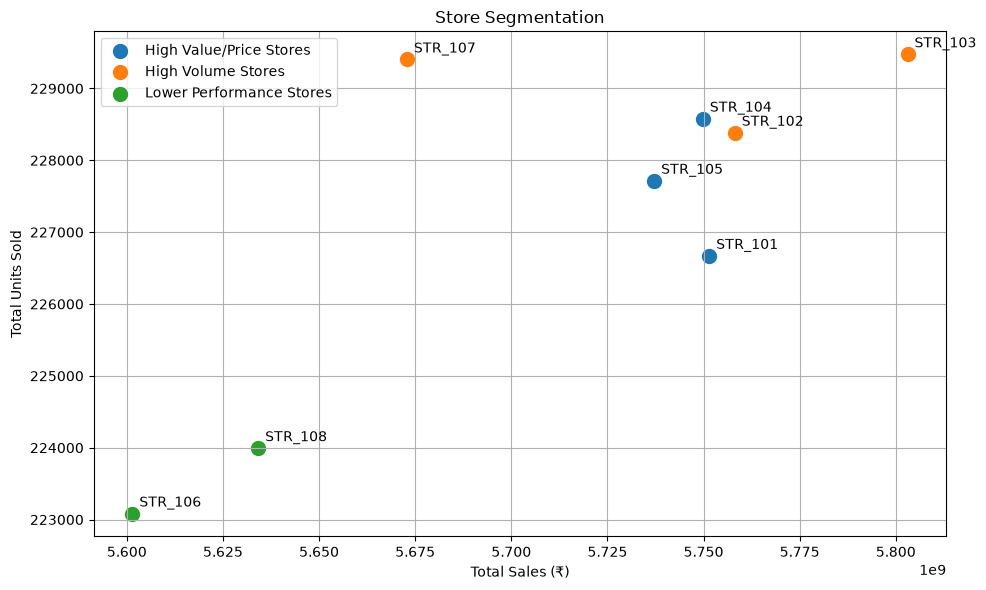

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for segment in store_data["Segment"].unique():
    segment_data = store_data[store_data["Segment"] == segment]
    
    plt.scatter(
        segment_data["Total_Sales"],
        segment_data["Total_Units_Sold"],
        s=100,
        label=segment
    )

    for _, row in segment_data.iterrows():
        plt.annotate(
            row["Store_ID"],
            (row["Total_Sales"], row["Total_Units_Sold"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.title("Store Segmentation")
plt.xlabel("Total Sales (₹)")
plt.ylabel("Total Units Sold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Save final store segmentation results

segmentation_file_path = "../data/store_segmentation.csv"

store_data.to_csv(
    segmentation_file_path,
    index=False
)

print("Store segmentation saved successfully!")
print("File:", segmentation_file_path)
print("Rows:", store_data.shape[0])
print("Columns:", store_data.shape[1])

Store segmentation saved successfully!
File: ../data/store_segmentation.csv
Rows: 8
Columns: 11
